In [ ]:
!pip install SimpleITK -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 15.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

In [ ]:
import gdown
import os

os.makedirs("data", exist_ok=True)

# MHD (header)
gdown.download(
    "https://drive.google.com/uc?id=1KIuaToQzioFQbQg6b_DiTLzN_2_0y7ph",
    "data/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd",
    quiet=False,
)

# RAW (voxels)
gdown.download(
    "https://drive.google.com/uc?id=1Iau3f1Byl0HMluwD5RRhCEalnt2ky4xI",
    "data/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.raw",
    quiet=False,
)

print("Download concluido!")

Downloading...
From: https://drive.google.com/uc?id=1KIuaToQzioFQbQg6b_DiTLzN_2_0y7ph
To: /content/data/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd
100%|██████████| 411/411 [00:00<00:00, 408kB/s]
Downloading...
From: https://drive.google.com/uc?id=1Iau3f1Byl0HMluwD5RRhCEalnt2ky4xI
To: /content/data/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.raw
100%|██████████| 62.4M/62.4M [00:00<00:00, 65.2MB/s]

Download concluido!


In [ ]:
# ALTERNATIVA: CT Scan sintetico (use apenas se o download falhar)
# Descomente as linhas abaixo:

# ct_array = np.random.randint(-1000, 400, size=(128, 256, 256)).astype(np.int16)
# ct_sitk = sitk.GetImageFromArray(ct_array)
# ct_sitk.SetSpacing((0.7, 0.7, 2.5))  # simula anisotropia real
# sitk.WriteImage(ct_sitk, "data/sintetico.mhd")
# print("CT sintetico criado!")

In [ ]:
mhd_path = "/content/data/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd"
ct_sitk = sitk.ReadImage(mhd_path)
ct_array = sitk.GetArrayFromImage(ct_sitk)


In [ ]:
type(ct_sitk)


SimpleITK.SimpleITK.Image

In [ ]:
type(ct_array)

numpy.ndarray

In [ ]:
ct_array.shape

(119, 512, 512)

In [ ]:
ct_array.dtype

dtype('int16')

In [ ]:
512*512

262144

In [ ]:
print(f"{ct_array.ndim}D")

3D


In [ ]:
spacing = ct_sitk.GetSpacing()
origin = ct_sitk.GetOrigin()

print(f"Espaçamento (x, y, z): {spacing} mm ")
print(f"Origem: {origin}")


Espaçamento (x, y, z): (0.7421879768371582, 0.7421879768371582, 2.5) mm 
Origem: (-182.5, -190.0, -313.75)


In [ ]:
fatia = ct_array[0]
print(f"Min: {fatia.min()}, Max: {fatia.max()}")

Min: -2048, Max: 1278


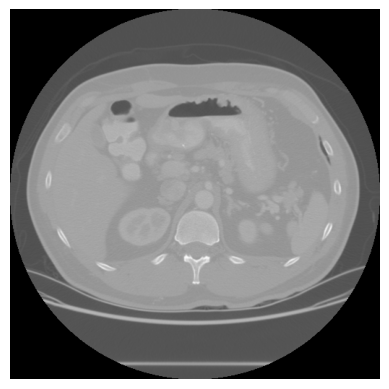

In [ ]:
plt.imshow(fatia, cmap="gray")
plt.axis("off")
plt.show()

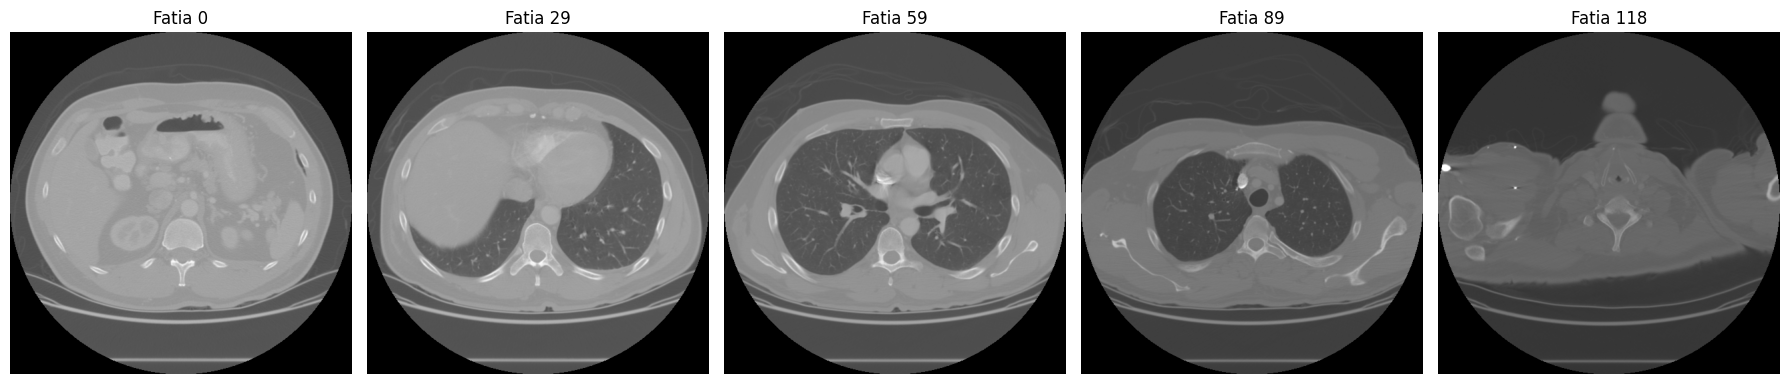

In [ ]:
n_fatias = ct_array.shape[0]
indices = [0, n_fatias // 4, n_fatias // 2, 3 * n_fatias // 4, n_fatias - 1]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, idx in zip(axes, indices):
    ax.imshow(ct_array[idx], cmap="gray")
    ax.set_title(f"Fatia {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
print(f"MIN: {ct_array.min()}")
print(f"MAX: {ct_array.max()}")

MIN: -2048
MAX: 3071


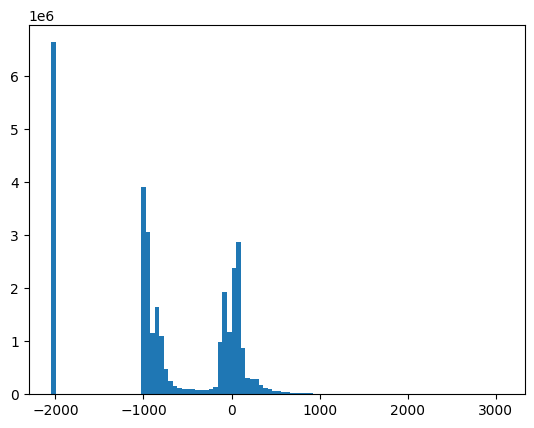

In [ ]:
plt.hist(ct_array.flatten(), bins=100);

In [ ]:
def aplicar_janela(img, center, width):
    lower = center - width // 2
    upper = center + width // 2
    img_janelada = np.clip(img, lower, upper)
    return img_janelada

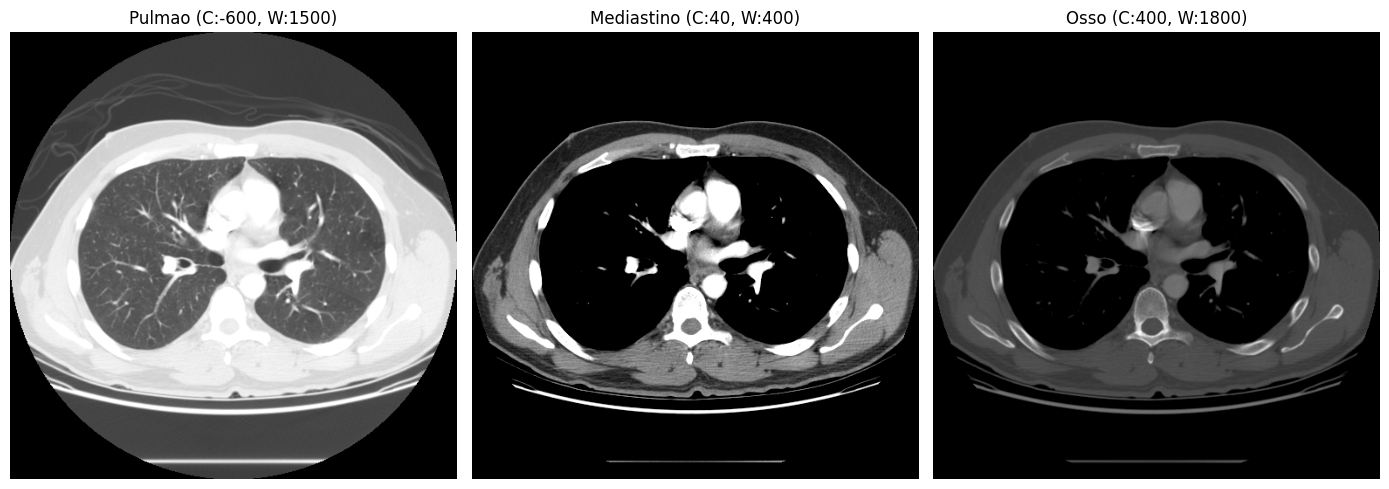

In [ ]:
fatia_meio = ct_array[ct_array.shape[0] // 2]

janelas = {
    "Pulmao (C:-600, W:1500)": (-600, 1500),
    "Mediastino (C:40, W:400)": (40, 400),
    "Osso (C:400, W:1800)": (400, 1800),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (nome, (center, width)) in zip(axes, janelas.items()):
    img = aplicar_janela(fatia_meio, center, width)
    ax.imshow(img, cmap="gray")
    ax.set_title(nome)
    ax.axis("off")
plt.tight_layout()
plt.show()

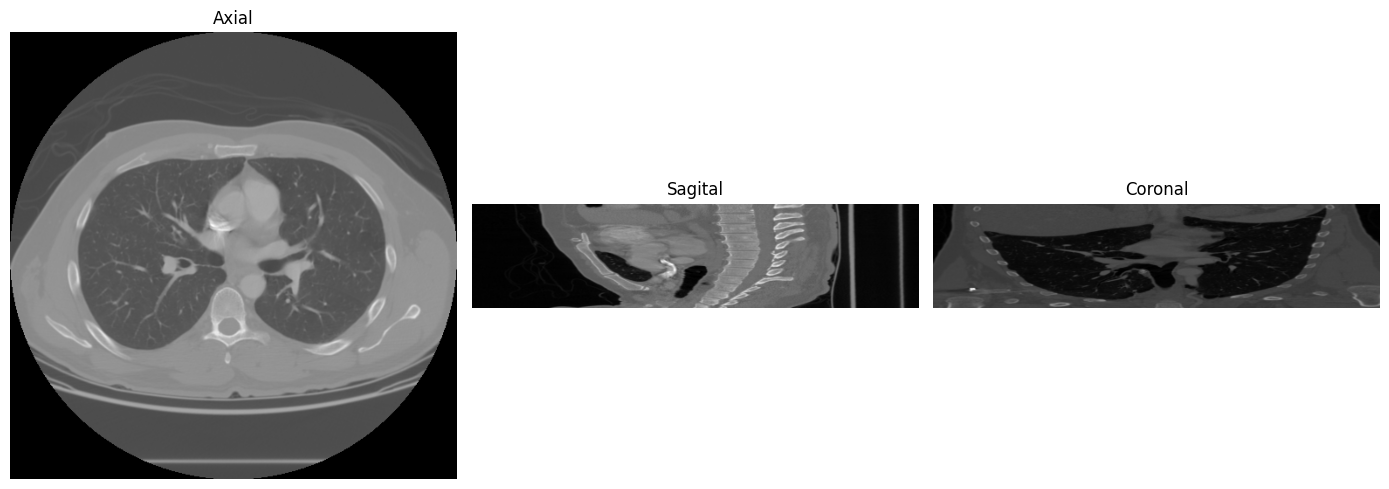

In [ ]:
d, h, w = ct_array.shape

axial = ct_array[d // 2]         # fatia no meio do eixo z
sagital = ct_array[:, :, w // 2]  # fatia no meio do eixo x
coronal = ct_array[:, h // 2, :]  # fatia no meio do eixo y

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(axial, cmap="gray")
axes[0].set_title("Axial")
axes[1].imshow(sagital, cmap="gray")
axes[1].set_title("Sagital")
axes[2].imshow(coronal, cmap="gray")
axes[2].set_title("Coronal")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
spacing = ct_sitk.GetSpacing()  # (x, y, z)
sx, sy, sz = spacing

print(f"Espacamento X: {sx:.3f} mm")
print(f"Espacamento Y: {sy:.3f} mm")
print(f"Espacamento Z: {sz:.3f} mm")
print(f"Razao Z/X: {sz/sx:.1f}x")

Espacamento X: 0.742 mm
Espacamento Y: 0.742 mm
Espacamento Z: 2.500 mm
Razao Z/X: 3.4x


In [ ]:
shape = ct_array.shape  # (z, y, x)
tamanho_mm = (
    shape[0] * sz,  # profundidade
    shape[1] * sy,  # altura
    shape[2] * sx,  # largura
)

print(f"Shape (voxels): {shape}")
print(f"Tamanho fisico: {tamanho_mm[0]:.0f} x {tamanho_mm[1]:.0f} x {tamanho_mm[2]:.0f} mm")
print(f"Tamanho fisico: {tamanho_mm[0]/10:.1f} x {tamanho_mm[1]/10:.1f} x {tamanho_mm[2]/10:.1f} cm")

Shape (voxels): (119, 512, 512)
Tamanho fisico: 298 x 380 x 380 mm
Tamanho fisico: 29.8 x 38.0 x 38.0 cm


In [ ]:
new_spacing = (1.0, 1.0, 1.0)

original_size = ct_sitk.GetSize()       # (x, y, z)
original_spacing = ct_sitk.GetSpacing() # (x, y, z)

new_size = [
    int(round(osz * ospc / nspc))
    for osz, ospc, nspc in zip(original_size, original_spacing, new_spacing)
]

print(f"Tamanho original: {original_size}")
print(f"Espacamento original: {original_spacing}")
print(f"Novo tamanho: {new_size}")
print(f"Novo espacamento: {new_spacing}")

Tamanho original: (512, 512, 119)
Espacamento original: (0.7421879768371582, 0.7421879768371582, 2.5)
Novo tamanho: [380, 380, 298]
Novo espacamento: (1.0, 1.0, 1.0)


In [ ]:
resampler = sitk.ResampleImageFilter()
resampler.SetOutputSpacing(new_spacing)
resampler.SetSize(new_size)
resampler.SetOutputDirection(ct_sitk.GetDirection())
resampler.SetOutputOrigin(ct_sitk.GetOrigin())
resampler.SetInterpolator(sitk.sitkLinear)

ct_resampled = resampler.Execute(ct_sitk)
ct_resampled_array = sitk.GetArrayFromImage(ct_resampled)

print(f"Shape original: {ct_array.shape}")
print(f"Shape resampleado: {ct_resampled_array.shape}")

Shape original: (119, 512, 512)
Shape resampleado: (298, 380, 380)


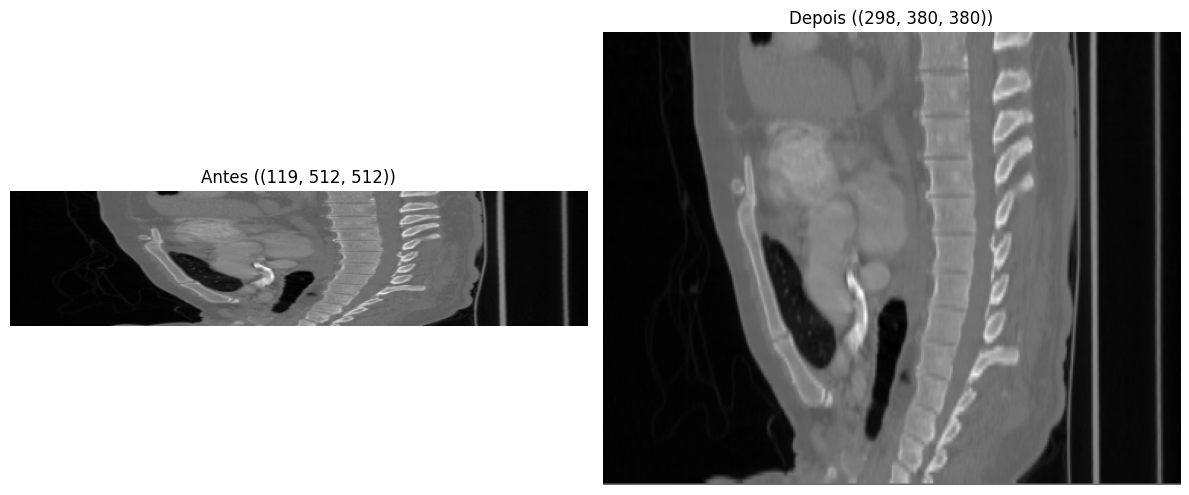

In [ ]:
sagital_antes = ct_array[:, :, ct_array.shape[2] // 2]
sagital_depois = ct_resampled_array[:, :, ct_resampled_array.shape[2] // 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(sagital_antes, cmap="gray")
axes[0].set_title(f"Antes ({ct_array.shape})")
axes[1].imshow(sagital_depois, cmap="gray")
axes[1].set_title(f"Depois ({ct_resampled_array.shape})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

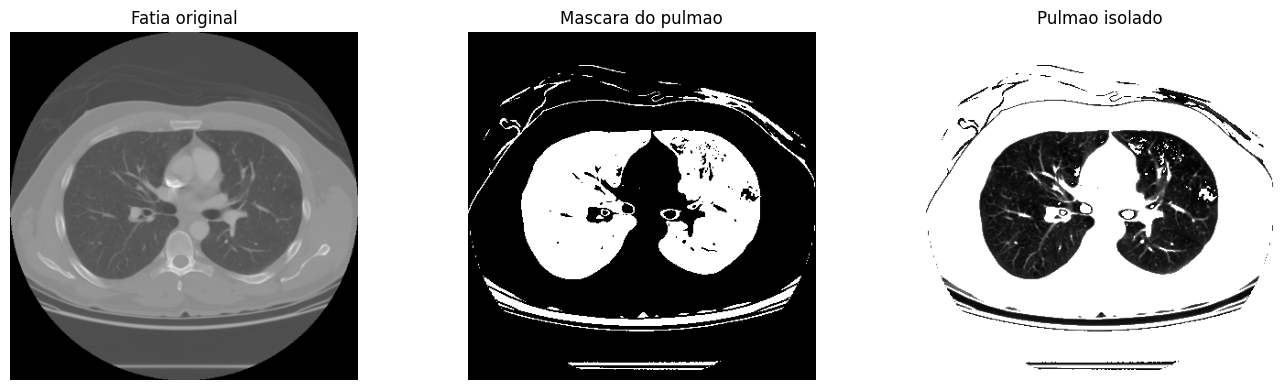

In [ ]:
fatia = ct_resampled_array[ct_resampled_array.shape[0] // 2]

mascara_pulmao = (fatia > -900) & (fatia < -400)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(fatia, cmap="gray")
axes[0].set_title("Fatia original")
axes[1].imshow(mascara_pulmao, cmap="gray")
axes[1].set_title("Mascara do pulmao")
axes[2].imshow(fatia * mascara_pulmao, cmap="gray")
axes[2].set_title("Pulmao isolado")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import torch

In [ ]:
ct_tensor = torch.from_numpy(ct_resampled_array.astype(np.float32))

In [ ]:
ct_tensor.dtype

torch.float32

In [ ]:
ct_tensor.shape

torch.Size([298, 380, 380])